In [1]:
from dataHandler import Config, MetadataHandler, OligosHandler, FeatureManager
from survival_helpers import *
from plots_helpers import *

from matplotlib.colors import LinearSegmentedColormap
import pickle
from joblib import load
from tabulate import tabulate
import math
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /home/creyna/miniconda3/envs/ML_env/lib/R
INFO:rpy2.situation:R library path: 
INFO:rpy2.situation:LD_LIBRARY_PATH: 
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [2]:
config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_trainTest.yaml"
#config_file = "/gpfs/data/fs71974/creynablanco/MLpackage/config_file_survival.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                     subgroup='all',
                                     with_oligos=True,
                                     with_additional_features=True,
                                     filter_by_entropy=False,
                                     prevalence_threshold_min=0,
                                     prevalence_threshold_max=100)

X_train, y_event_train = feature_manager.get_features_target()
y_time_train = X_train["OS months"]
X_train.drop(columns=["OS months"], inplace=True)
y_time_train = y_time_train.where(y_event_train == 1, -y_time_train)

config_file = "/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/config_survival_withTKI.yaml"
config = Config(config_file)
metadata_handler = MetadataHandler(config)
oligos_handler = OligosHandler(config)
feature_manager = FeatureManager(config, metadata_handler, oligos_handler,
                                     subgroup='all',
                                     with_additional_features=True,
                                     prevalence_threshold_min=0,
                                     prevalence_threshold_max=100)
X_test, y_event_test = feature_manager.get_features_target()
y_time_test = X_test["OS months"]
X_test.drop(columns=["OS months"], inplace=True)
y_time_test = y_time_test.where(y_event_test == 1, -y_time_test)
with open('/home/creyna/Vogl-lab_Projects_git/HCC/y_time_test.pkl', 'wb') as file:
    pickle.dump(y_time_test, file)

In [3]:
print(f"Test:{X_train.shape}")
print(f"test:{X_test.shape}")

Test:(73, 8011)
test:(27, 8011)


In [4]:
number_peptides = f"{X_test.shape[1]}"

In [5]:
model_ids = [62, 79, 36, 32, 20, 42, 45, 64, 1, 17] #list(range(1, 100))#
# Prepare an empty list to collect each model's metrics
time_dependent_auc_test = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
time_dependent_auc_test_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_test_full = pd.Series(None, index=model_ids)

time_dependent_auc_antigen_test_full = pd.DataFrame(None, columns=range(1, 25), index=model_ids)
mean_auc_antigen_test_full = pd.Series(None, index=model_ids)

risk_scores_test = pd.DataFrame(None, columns=model_ids, index=X_test.index)
test_shap_values =  pd.DataFrame(0.0, index=X_test.index, columns=X_test.columns)

c_index_test = pd.Series(None, index=model_ids)
c_index_test_ipcw = pd.Series(None, index=model_ids)
c_index_test_censoring = pd.Series(None, index=model_ids)
time_points =  np.arange(1, 25, step=1)

with open("/home/creyna/Vogl-lab_Projects_git/HCC/top_peptides_repeats.pkl", "rb") as f:
    top_peptides_train = pickle.load(f)
with open("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scaler_train_rep.pkl", "rb") as f:
    antigen_scaler_train_rep = pickle.load(f)
with open("/home/creyna/Vogl-lab_Projects_git/HCC/shap_scaler_train_rep.pkl", "rb") as f:
    shap_scaler_train_rep = pickle.load(f)

file_path_template = "/home/creyna/Vogl-lab_Projects_git/HCC/results_evaluationTrainingIT/reevaluation_nested_cv_results_bestmodel_auc_{}.joblib"
for model_id in model_ids:
    # Construct the file path for the model results based on its ID/seed.
    # Adjust the path and filename format as needed.
    file_path = file_path_template.format(model_id)
    results = load(file_path)

    # Get risk scores from the results (assuming they're stored as 'risk_scores_test')
    test_shap_values.loc[results['test_shap_values'].index, results['test_shap_values'].columns] += results['test_shap_values']

    full_shap_values =  pd.DataFrame(0.0, index=X_test.index, columns=X_test.columns)
    full_shap_values.loc[results['test_shap_values'].index, results['test_shap_values'].columns] = results['test_shap_values']
    antigen_scores_time_event_test_rep = calculate_antigen_scores_scaled(full_shap_values, y_time_test.abs(), y_event_test, top_peptides_train,
                                                                         scaler=shap_scaler_train_rep.loc[model_id],
                                                                         scaler_antigens=antigen_scaler_train_rep.loc[model_id],
                                                                         return_all = False)
    auc_antigen_values_test, mean_auc_antigen = calculate_cumulative_dynamic_auc(y_time_train, y_time_test,
                                                                      antigen_scores_time_event_test_rep['Antigen Score (Scaled)'], time_points)
    time_dependent_auc_antigen_test_full.loc[model_id] = auc_antigen_values_test
    mean_auc_antigen_test_full.loc[model_id] = mean_auc_antigen

    risk_scores_test.loc[:, model_id] = results['risk_scores_test']
    time_dependent_auc_test.loc[model_id] = results['time_dependent_auc_test']
    auc_values_test, mean_auc_test = calculate_cumulative_dynamic_auc(y_time_train, y_time_test,
                                                                      risk_scores_test.loc[:, model_id], time_points)
    time_dependent_auc_test_full.loc[model_id] = auc_values_test
    mean_auc_test_full.loc[model_id] = mean_auc_test

    c_index_test.loc[model_id] = results['c_index_test']
    c_index_test_ipcw.loc[model_id] = c_index_scorer_ipcw(y_time_train, y_time_test, risk_scores_test.loc[:, model_id].values)
    c_index_test_censoring.loc[model_id] = c_index_scorer(y_time_test, risk_scores_test.loc[:, model_id].values)

test_shap_values /= len(model_ids)
#top_peptides_test = test_shap_values.abs().mean(0).sort_values(ascending=False).head(15).index
#with open('top_peptides_test.pkl', 'wb') as file:
#    pickle.dump(top_peptides_test, file)

/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

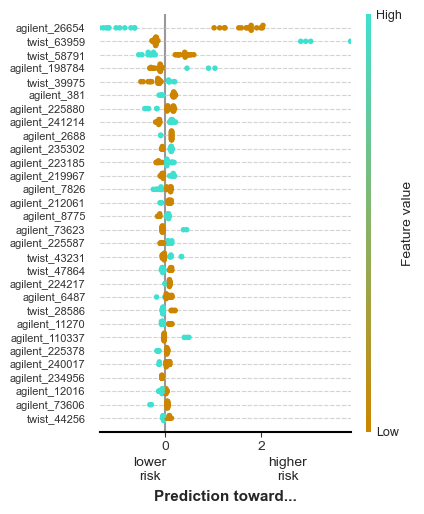

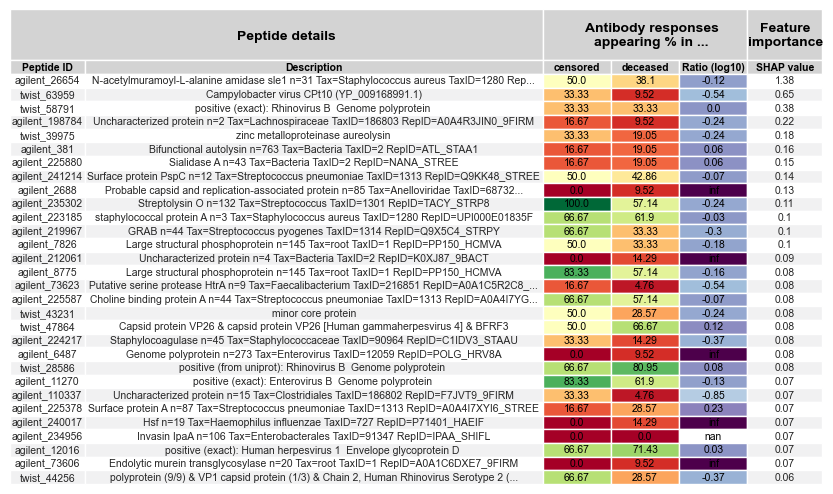

In [6]:
newCmap = LinearSegmentedColormap.from_list("",  ['#CD8500', '#40E0D0'])

plot_shap_values(test_shap_values.values, X_test, cmap=newCmap, max_display=30,
                 label_groups = ['lower\nrisk', 'higher\nrisk'], suffix_file=f'xgb_Cox-Hazard_testingSet_{number_peptides}',
                 save_fig = True,  figures_dir = config.figures_dir )

oligos_metadata = oligos_handler.get_oligos_metadata_df()[['Description', 'full name', 'len_seq', 'pos', 'Organism_complete_name']]
y_event_test.name = config.col_target  # Naming the Series since it currently has no name
feature_importance_test = generate_feature_importance_table(test_shap_values.values, X_test, y_event_test, oligos_metadata,
                                                             group_tests = config.group_tests, suffix_file=f'xgb_Cox-Hazard_testingSet_{number_peptides}', figures_dir = config.figures_dir)
plot_table_top_features(feature_importance_test,
                        to_select_features = 30,
                        group_tests = config.group_tests,
                        figure_dir = config.figures_dir, suffix_file =f'xgb_Cox-Hazard_testingSet_{number_peptides}', save_fig = True)

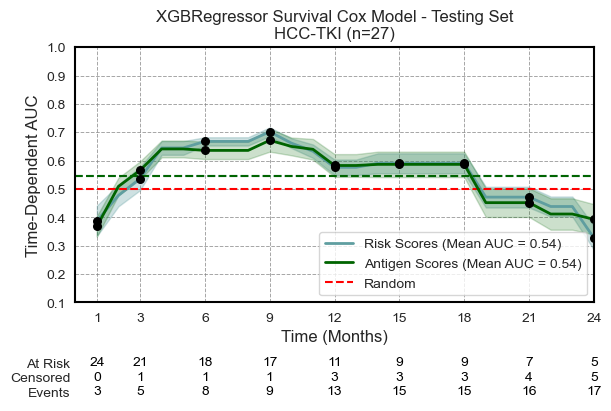

In [7]:
time_points_highlight = np.concatenate(([1], np.arange(3, 25, step=3)))
# Risk Scores
se_auc_curve = time_dependent_auc_test_full.std() / np.sqrt(time_dependent_auc_test_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_test_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_test_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_values_test = time_dependent_auc_test_full.mean(skipna=True)
samples_at_risk_test = calculate_samples_at_risk(y_time_test, time_points_highlight)

fig = plot_time_dependent_auc(auc_values_test, samples_at_risk_test,
                        mean_auc=mean_auc_test_full.mean(),
                        ci_lower=ci_lower, ci_upper=ci_upper,
                        time_points_highlight=time_points_highlight,
                        time_measure = "Months", max_time_point = 24,
                        color_auc = "CadetBlue", color_mean="CadetBlue", color_ci="CadetBlue",
                        figures_dir = config.figures_dir, save_fig=False)

# Antigen Scores
se_auc_curve = time_dependent_auc_antigen_test_full.std() / np.sqrt(time_dependent_auc_antigen_test_full.shape[0])
ci_lower =  np.asarray(time_dependent_auc_antigen_test_full.mean() - 1.96 * se_auc_curve, dtype=float)
ci_upper = np.asarray(time_dependent_auc_antigen_test_full.mean() + 1.96 * se_auc_curve, dtype=float)
auc_antigen_values_test = time_dependent_auc_antigen_test_full.mean(skipna=True)

ax_auc = fig.get_axes()[0]
ax_auc.plot(auc_antigen_values_test.index, auc_antigen_values_test.values, color="DarkGreen", linestyle='-', linewidth=2)
ax_auc.axhline(y=mean_auc_antigen_test_full.mean(), color="DarkGreen", linestyle='--', linewidth=1.5)
ax_auc.scatter(time_points_highlight, auc_antigen_values_test[time_points_highlight], color="black", s=30, zorder=3)
ax_auc.fill_between(time_points, ci_lower, ci_upper, color='DarkGreen', alpha=0.2)
ax_auc.set_ylim(0.1,1.0)
handles = ax_auc.get_lines()
handles=[handles[i] for i in [0, 3, 2]]
ax_auc.set_title("XGBRegressor Survival Cox Model - Testing Set\nHCC-TKI (n=27)", fontsize=12)
ax_auc.legend(handles, [f"Risk Scores (Mean AUC = {mean_auc_test_full.mean():.2f})",
                        f"Antigen Scores (Mean AUC = {mean_auc_antigen_test_full.mean():.2f})",
                        "Random"], fontsize=10, loc='lower right')
save_path = Path(config.figures_dir) / f'time-dependent_auc_riskScore-antigenScore_testingSet_allData_{number_peptides}.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [8]:
with open("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_threshold_train.pkl", "rb") as f:
    antigen_threshold_train = pickle.load(f)
with open("/home/creyna/Vogl-lab_Projects_git/HCC/antigen_scaler_train.pkl", "rb") as f:
    antigen_scaler_train = pickle.load(f)
with open("/home/creyna/Vogl-lab_Projects_git/HCC/shap_scaler_train.pkl", "rb") as f:
    shap_scaler_train = pickle.load(f)
antigen_scores_time_event_test = calculate_antigen_scores_scaled(test_shap_values, y_time_test.abs(), y_event_test, top_peptides_train,
                                                                 threshold=antigen_threshold_train, scaler=shap_scaler_train, scaler_antigens=antigen_scaler_train, return_all = False)

INFO:survival_helpers:Figure saved to /home/creyna/Vogl-lab_Projects_git/HCC/Data/Predictions/Figures/figures_censored-deceased/kaplan_meier_xgb_Cox-Hazard_testingSet_8011.png
INFO:survival_helpers:Log-Rank Test p-value: 0.8680


0.868004897168289

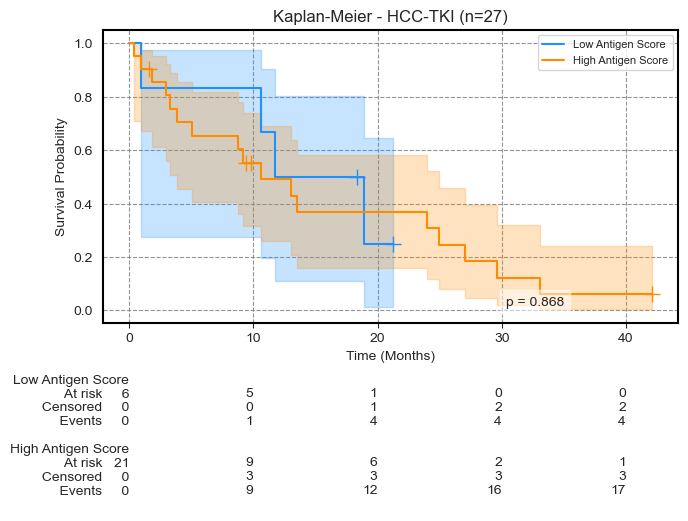

In [9]:
# Assuming the antigen score has been dichotomized into "Antigen Score (Dichotomized)" and you have time and event data in a data frame
labels = {0: 'Low Antigen Score', 1: 'High Antigen Score'}

# Plot for Training Set
plot_kaplan_meier(antigen_scores_time_event_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)', labels,
                  title="Kaplan-Meier - HCC-TKI (n=27)",
                  xlabel="Time (Months)", ylabel="Survival Probability",
                  save_fig=True, figures_dir=config.figures_dir, suffix_file=f'xgb_Cox-Hazard_testingSet_{number_peptides}')
# Perform log-rank test for Training Set
perform_logrank_test(antigen_scores_time_event_test, 'OS months', 'OS Status', 'Antigen Score (Dichotomized)')

In [10]:
top_peptides_df = feature_manager.get_data_with_target()[top_peptides_train].droplevel(0)
clinical_meta = metadata_handler.get_individuals_metadata_df()
clinical_meta = pd.concat([clinical_meta,
                         pd.concat([antigen_scores_time_event_test.iloc[:,2:], risk_scores_test.mean(axis=1).to_frame().rename(columns={0: "Risk Score"})], axis=1, names=["SampleName"]), top_peptides_df],  axis = 1)
# Replace 1 with the name of the peptide and 0 with "absence"
for peptide_column in top_peptides_train:
    clinical_meta[peptide_column] = clinical_meta[peptide_column].apply(
        lambda x: 'presence' if x == 1 else 'absence'
    )
clinical_meta['Sex_ctg'] = clinical_meta['Sex'].apply(lambda x: "Male" if x == 1 else "Female")

clinical_meta['Age_ctg'] = clinical_meta['Age'].apply(lambda x: ">=65" if x >=65 else "<65")

clinical_meta['AFP 100_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=100" if x >=100 else "<100")
clinical_meta['AFP 400_ctg'] = clinical_meta['AFP'].apply(lambda x: ">=400" if x >=400 else "<400")


clinical_meta['Cirrhosis_ctg'] = clinical_meta['Cirrhosis_ctg'].apply(lambda x: "cirrhosis" if x == "yes" else "no cirrhosis")
clinical_meta['Cirrhosis_ctg'] = pd.Categorical(clinical_meta['Cirrhosis_ctg'],
                                                     categories=["no cirrhosis","cirrhosis"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["Child-Pugh stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage B": "Child-Pugh stage B"})], axis=1)
clinical_meta['MVI_ctg'] = clinical_meta['MVI_ctg'].apply(lambda x: "MVI" if x == "yes" else "no MVI")
clinical_meta['MVI_ctg'] = pd.Categorical(clinical_meta['MVI_ctg'],
                                                     categories=["no MVI","MVI"], ordered=True)
clinical_meta['EHS_ctg'] = clinical_meta['EHS_ctg'].apply(lambda x: "EHS" if x == "yes" else "no EHS")
clinical_meta['EHS_ctg'] = pd.Categorical(clinical_meta['EHS_ctg'],
                                                     categories=["no EHS","EHS"], ordered=True)

# Merge "stage A" and "stage B" into "stage AB"
clinical_meta['BCLC stage_ctg'] = clinical_meta['BCLC stage_ctg'].replace({'stage A': 'stage AB', 'stage B': 'stage AB'})
clinical_meta['BCLC stage_ctg'] = pd.Categorical(clinical_meta['BCLC stage_ctg'],
                                                     categories=["stage AB", "stage C"], ordered=True)
clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["BCLC stage_ctg"], drop_first=True, dtype=int).rename(columns={"stage C": "BCLC stage C"})], axis=1)

clinical_meta['Antigen Score (Dichotomized) ctg'] = clinical_meta['Antigen Score (Dichotomized)'].apply(lambda x: "Low Antigen Score" if x == 0 else "High Antigen Score")
clinical_meta['Antigen Score (Dichotomized) ctg'] = pd.Categorical(clinical_meta['Antigen Score (Dichotomized) ctg'],
                                                     categories=["Low Antigen Score", "High Antigen Score"], ordered=True)

clinical_meta = pd.concat([clinical_meta, pd.get_dummies(clinical_meta["mRECIST_ctg"], drop_first=True, dtype=int)], axis = 1)
clinical_meta.to_excel("/home/creyna/Vogl-lab_Projects_git/HCC/Metadata/HCC_TKI_metadata_with_scores.xlsx", index=True)


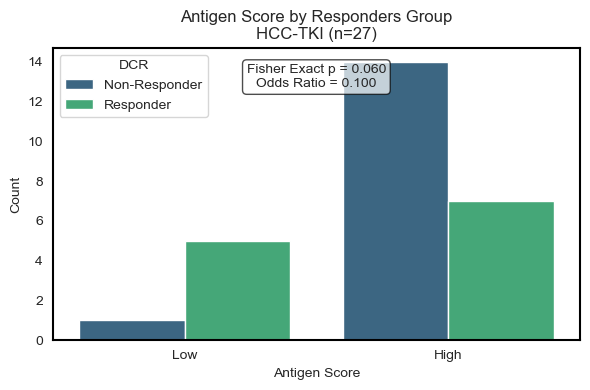

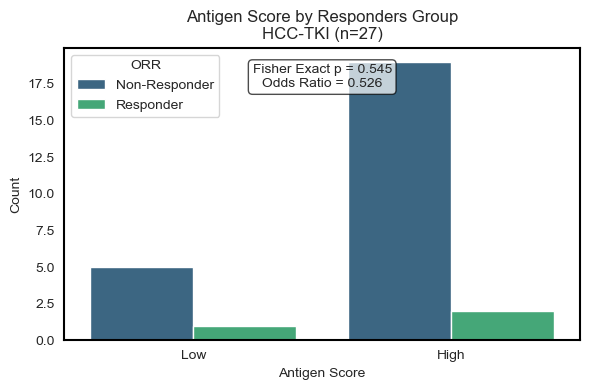

In [11]:
mapping = {0.0: 'Non-Responder', 1.0: 'Responder'}
mapping_antigen = {0: 'Low', 1: 'High'}

# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='DCR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    title="Antigen Score by Responders Group\nHCC-TKI (n=27)",
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"test_antigenScore_DCR_{number_peptides}"
)
# Call the function
fig = barplot_counts_fisher_test(
    df=clinical_meta,
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    title="Antigen Score by Responders Group\nHCC-TKI (n=27)",
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"test_antigenScore_ORR{number_peptides}"
)

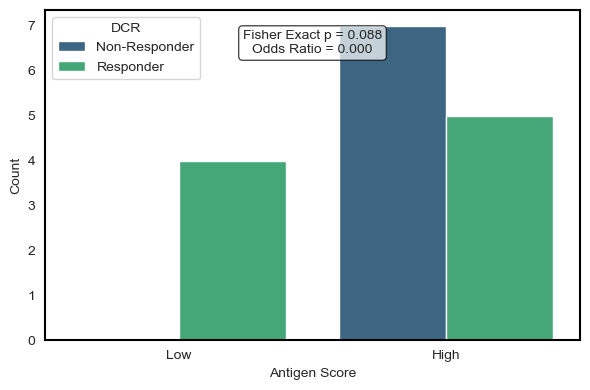

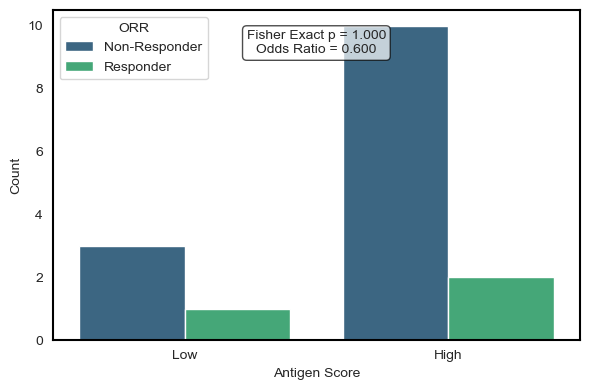

In [12]:
child_pugh_A_df = clinical_meta[clinical_meta['Child-Pugh stage'] == 1]
# Call the function1
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='DCR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='DCR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"test_childPughA_antigenScore_DCR_{number_peptides}"
)

# Call the function
fig = barplot_counts_fisher_test(
    df=child_pugh_A_df,
    cat_var1='ORR',
    cat_var2='Antigen Score (Dichotomized)',
    legend_title='ORR',
    y_label='Count',
    x_label='Antigen Score',
    mapping1=mapping,
    mapping2=mapping_antigen,
    figsize=(6, 4),
    palette='viridis',
    save_path=config.figures_dir,
    suffix_file=f"test_childPughA_antigenScore_ORR_{number_peptides}"
)

Mann–Whitney Test statistic: 137.0, p-value: 0.023
Mann–Whitney Test statistic: 40.0, p-value: 0.799


/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/creyna/miniconda3/envs/ML_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119

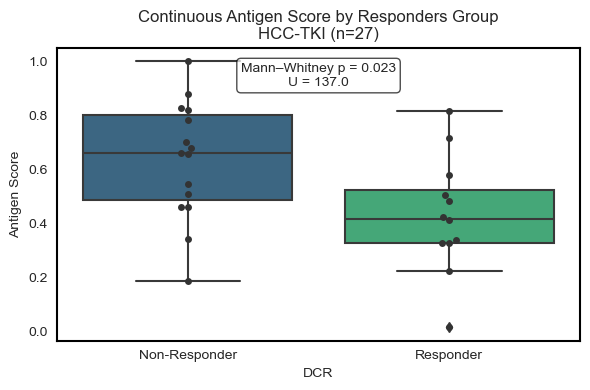

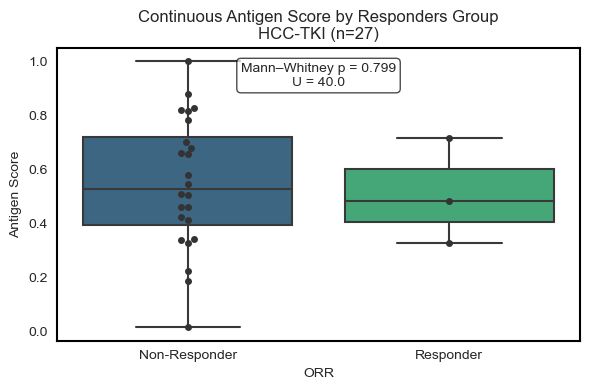

In [13]:
fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               cat_var='DCR',
                                               title="Continuous Antigen Score by Responders Group\nHCC-TKI (n=27)",
                                               cat_mapping=mapping,
                                               x_label="DCR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(6,4),
                                               # save_path=config.figures_dir,
                                               # suffix_file=f"antigenScore_DCR_{number_peptides}"
                                               )

fig = boxplot_compare_distribution_by_category(clinical_meta,
                                               cont_var='Antigen Score (Scaled)',
                                               cat_var='ORR',
                                               cat_mapping=mapping,
                                               title="Continuous Antigen Score by Responders Group\nHCC-TKI (n=27)",
                                               x_label="ORR",
                                               y_label="Antigen Score",
                                               #title="Antigen Score by DCR Group",
                                               figsize=(6,4),
                                               #save_path=config.figures_dir,
                                               #suffix_file=f"antigenScore_ORR_{number_peptides}"
                                               )